<a href="https://colab.research.google.com/github/reezyhudson865/DataProjects/blob/main/RHudson_TSA_ClaimsData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 10 Lab**

The following lab was completed in an undergrad data science class at UT-Knoxville in the Spring 2026 semester. The lab follows TSA insurance claims at American airports. It includes a series of visual analyses. The lab objective was outlined by the professor. All rights reserved.

In [ ]:
!pip install geopandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import zipfile
import os
import glob

In [ ]:
tsa_path = "tsa_claims2.csv"
airport_path = "GlobalAirportDatabase.csv"

tsa = pd.read_csv(tsa_path, low_memory=False)
airports = pd.read_csv(airport_path, low_memory=False)

print("TSA shape:", tsa.shape)
print("Airport shape:", airports.shape)

print("\nTSA columns:")
print(tsa.columns.tolist())

print("\nAirport columns:")
print(airports.columns.tolist())

TSA shape: (204267, 13)
Airport shape: (9300, 16)

TSA columns:
['Claim Number', 'Date Received', 'Incident Date', 'Airport Code', 'Airport Name', 'Airline Name', 'Claim Type', 'Claim Site', 'Item', 'Claim Amount', 'Status', 'Close Amount', 'Disposition']

Airport columns:
['ICAOCode', 'IATACode', 'AirportName', 'City', 'Country', 'LatitudeDegrees', 'LatitudeMinutes', 'LatitudeSeconds', 'LatitudeDir', 'LongitudeDegrees', 'LongitudeMinutes', 'LongitudeSeconds', 'LongitudeDirection', 'Altitude', 'LatitudeDecimalDegrees', 'LongitudeDecimalDegrees']


In [ ]:
#clean tsa_claims

tsa.columns = tsa.columns.str.strip()

#standardize the text columns
tsa["Claim Number"] = tsa["Claim Number"].astype(str).str.strip().str.upper()
tsa["Airport Code"] = tsa["Airport Code"].astype(str).str.strip().str.upper()
tsa["Airport Name"] = tsa["Airport Name"].astype(str).str.strip().str.title()
tsa["Airline Name"] = tsa["Airline Name"].astype(str).str.strip().str.title()
tsa["Claim Type"] = tsa["Claim Type"].astype(str).str.strip().str.title()
tsa["Claim Site"] = tsa["Claim Site"].astype(str).str.strip().str.title()
tsa["Item"] = tsa["Item"].astype(str).str.strip().str.title()
tsa["Status"] = tsa["Status"].astype(str).str.strip().str.title()
tsa["Disposition"] = tsa["Disposition"].astype(str).str.strip().str.title()

#replace the blank text values with NaN
tsa = tsa.replace({
    "": np.nan,
    " ": np.nan,
    "-": np.nan,
    "Nan": np.nan,
    "None": np.nan,
    "NULL": np.nan,
    "Null": np.nan
})

#parse the dates
tsa["Date Received"] = pd.to_datetime(tsa["Date Received"], errors="coerce")
tsa["Incident Date"] = pd.to_datetime(tsa["Incident Date"], errors="coerce")

#fix the future dates
today = pd.Timestamp.today().normalize()
tsa.loc[tsa["Date Received"] > today, "Date Received"] = tsa.loc[tsa["Date Received"] > today, "Date Received"] - pd.DateOffset(years=100)
tsa.loc[tsa["Incident Date"] > today, "Incident Date"] = tsa.loc[tsa["Incident Date"] > today, "Incident Date"] - pd.DateOffset(years=100)

#clean the currency columns
tsa["Claim Amount"] = tsa["Claim Amount"].astype(str).str.strip()
tsa["Claim Amount"] = tsa["Claim Amount"].str.replace("$", "", regex=False)
tsa["Claim Amount"] = tsa["Claim Amount"].str.replace(",", "", regex=False)
tsa["Claim Amount"] = tsa["Claim Amount"].replace("-", np.nan)
tsa["Claim Amount"] = pd.to_numeric(tsa["Claim Amount"], errors="coerce")


tsa["Close Amount"] = tsa["Close Amount"].astype(str).str.strip()
tsa["Close Amount"] = tsa["Close Amount"].str.replace("$", "", regex=False)
tsa["Close Amount"] = tsa["Close Amount"].str.replace(",", "", regex=False)
tsa["Close Amount"] = tsa["Close Amount"].str.replace("(", "-", regex=False)
tsa["Close Amount"] = tsa["Close Amount"].str.replace(")", "", regex=False)
tsa["Close Amount"] = pd.to_numeric(tsa["Close Amount"], errors="coerce")

#standardize the repeated category values
tsa["Disposition"] = tsa["Disposition"].replace({
    "Approve In Full": "Approved",
    "Settle": "Settled",
    "Deny": "Denied"
})

tsa["Status"] = tsa["Status"].replace({
    "Approve In Full": "Approved",
    "Settle": "Settled",
    "Deny": "Denied"
})

#remove any exact duplicates
tsa = tsa.drop_duplicates()

#add year columns
tsa["Received Year"] = tsa["Date Received"].dt.year
tsa["Incident Year"] = tsa["Incident Date"].dt.year

print("\nCleaned TSA shape:", tsa.shape)
print("\nTSA missing values:")
print(tsa.isna().sum())

print("\nTSA dtypes:")
print(tsa.dtypes)

print("\nTSA preview:")
print(tsa.head())

/var/folders/p1/dm_q2gn9307cw3qq2p3w808m0000gn/T/ipykernel_16440/73884754.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tsa["Date Received"] = pd.to_datetime(tsa["Date Received"], errors="coerce")



Cleaned TSA shape: (204266, 15)

TSA missing values:
Claim Number         0
Date Received      263
Incident Date    19870
Airport Code       441
Airport Name      8964
Airline Name     38620
Claim Type        8195
Claim Site        1016
Item              8389
Claim Amount     35679
Status           12757
Close Amount     70964
Disposition      72907
Received Year      263
Incident Year    19870
dtype: int64

TSA dtypes:
Claim Number             object
Date Received    datetime64[ns]
Incident Date    datetime64[ns]
Airport Code             object
Airport Name             object
Airline Name             object
Claim Type               object
Claim Site               object
Item                     object
Claim Amount            float64
Status                   object
Close Amount            float64
Disposition              object
Received Year           float64
Incident Year           float64
dtype: object

TSA preview:
    Claim Number Date Received Incident Date Airport Code  \
0     

In [ ]:
#clean GlobalAirportDatabase

#strip the spaces from column names
airports.columns = airports.columns.str.strip()

#clean the text columns
airports["ICAOCode"] = airports["ICAOCode"].astype(str).str.strip().str.upper()
airports["IATACode"] = airports["IATACode"].astype(str).str.strip().str.upper()
airports["AirportName"] = airports["AirportName"].astype(str).str.strip().str.title()
airports["City"] = airports["City"].astype(str).str.strip().str.title()
airports["Country"] = airports["Country"].astype(str).str.strip().str.upper()
airports["LatitudeDir"] = airports["LatitudeDir"].astype(str).str.strip().str.upper()
airports["LongitudeDirection"] = airports["LongitudeDirection"].astype(str).str.strip().str.upper()

#replace the blanks with NaN
airports = airports.replace({
    "": np.nan,
    " ": np.nan,
    "-": np.nan,
    "Nan": np.nan,
    "None": np.nan,
    "NULL": np.nan,
    "Null": np.nan
})

#convert the numeric columns
airports["LatitudeDegrees"] = pd.to_numeric(airports["LatitudeDegrees"], errors="coerce")
airports["LatitudeMinutes"] = pd.to_numeric(airports["LatitudeMinutes"], errors="coerce")
airports["LatitudeSeconds"] = pd.to_numeric(airports["LatitudeSeconds"], errors="coerce")
airports["LongitudeDegrees"] = pd.to_numeric(airports["LongitudeDegrees"], errors="coerce")
airports["LongitudeMinutes"] = pd.to_numeric(airports["LongitudeMinutes"], errors="coerce")
airports["LongitudeSeconds"] = pd.to_numeric(airports["LongitudeSeconds"], errors="coerce")
airports["Altitude"] = pd.to_numeric(airports["Altitude"], errors="coerce")
airports["LatitudeDecimalDegrees"] = pd.to_numeric(airports["LatitudeDecimalDegrees"], errors="coerce")
airports["LongitudeDecimalDegrees"] = pd.to_numeric(airports["LongitudeDecimalDegrees"], errors="coerce")

#fill the missing airport names with city
airports["AirportName"] = airports["AirportName"].fillna(airports["City"])

#remove the duplicates
airports = airports.drop_duplicates()

#keep only rows with IATA code
airports_join = airports.dropna(subset=["IATACode"]).copy()

#keep only rows with valid coordinates for mapping
airports_map = airports_join.dropna(subset=["LatitudeDecimalDegrees", "LongitudeDecimalDegrees"]).copy()

#remove the rows with 0,0 coordinates
airports_map = airports_map[
    ~(
        (airports_map["LatitudeDecimalDegrees"] == 0) &
        (airports_map["LongitudeDecimalDegrees"] == 0)
    )
].copy()

#keep U.S. airports
airports_us = airports_map[airports_map["Country"] == "USA"].copy()

#keep one row per IATA code
airports_us = airports_us.drop_duplicates(subset=["IATACode"])

print("\nCleaned airports shape:", airports.shape)
print("Airports for join shape:", airports_join.shape)
print("U.S. airports for map shape:", airports_us.shape)

print("\nAirport missing values:")
print(airports.isna().sum())

print("\nAirport dtypes:")
print(airports.dtypes)

print("\nAirport preview:")
print(airports.head())


Cleaned airports shape: (9300, 16)
Airports for join shape: (9300, 16)
U.S. airports for map shape: (475, 16)

Airport missing values:
ICAOCode                   0
IATACode                   0
AirportName                2
City                       2
Country                    0
LatitudeDegrees            0
LatitudeMinutes            0
LatitudeSeconds            0
LatitudeDir                0
LongitudeDegrees           0
LongitudeMinutes           0
LongitudeSeconds           0
LongitudeDirection         0
Altitude                   0
LatitudeDecimalDegrees     0
LongitudeDecimalDegrees    0
dtype: int64

Airport dtypes:
ICAOCode                    object
IATACode                    object
AirportName                 object
City                        object
Country                     object
LatitudeDegrees              int64
LatitudeMinutes              int64
LatitudeSeconds              int64
LatitudeDir                 object
LongitudeDegrees             int64
LongitudeMinutes    

In [ ]:
#extract and clean maps.zip

extract_folder = "maps_extracted"
os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile("maps.zip", "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("\nExtracted files before cleanup:")
for root, dirs, files in os.walk(extract_folder):
    for f in files:
        print(os.path.join(root, f))

#remove the __MACOSX files and dot-underscore files
for root, dirs, files in os.walk(extract_folder, topdown=False):
    for f in files:
        full_path = os.path.join(root, f)
        if "__MACOSX" in full_path or f.startswith("._"):
            os.remove(full_path)
    for d in dirs:
        full_dir = os.path.join(root, d)
        if "__MACOSX" in full_dir:
            try:
                os.rmdir(full_dir)
            except:
                pass

print("\nFiles after cleanup:")
for root, dirs, files in os.walk(extract_folder):
    for f in files:
        print(os.path.join(root, f))

#find the shapefile parts
shp_files = glob.glob(os.path.join(extract_folder, "**", "*.shp"), recursive=True)
dbf_files = glob.glob(os.path.join(extract_folder, "**", "*.dbf"), recursive=True)
shx_files = glob.glob(os.path.join(extract_folder, "**", "*.shx"), recursive=True)
prj_files = glob.glob(os.path.join(extract_folder, "**", "*.prj"), recursive=True)

print("\nShapefile parts found:")
print("SHP:", shp_files)
print("DBF:", dbf_files)
print("SHX:", shx_files)
print("PRJ:", prj_files)


Extracted files before cleanup:
maps_extracted/maps/states.dbf
maps_extracted/maps/states.sbx
maps_extracted/maps/states.shx
maps_extracted/maps/states.shp
maps_extracted/maps/states.shp.xml
maps_extracted/maps/states.sbn
maps_extracted/maps/states.prj
maps_extracted/__MACOSX/._maps
maps_extracted/__MACOSX/maps/._states.dbf
maps_extracted/__MACOSX/maps/._states.shx
maps_extracted/__MACOSX/maps/._states.sbx
maps_extracted/__MACOSX/maps/._states.shp
maps_extracted/__MACOSX/maps/._states.sbn
maps_extracted/__MACOSX/maps/._states.prj
maps_extracted/__MACOSX/maps/._states.shp.xml

Files after cleanup:
maps_extracted/maps/states.dbf
maps_extracted/maps/states.sbx
maps_extracted/maps/states.shx
maps_extracted/maps/states.shp
maps_extracted/maps/states.shp.xml
maps_extracted/maps/states.sbn
maps_extracted/maps/states.prj

Shapefile parts found:
SHP: ['maps_extracted/maps/states.shp']
DBF: ['maps_extracted/maps/states.dbf']
SHX: ['maps_extracted/maps/states.shx']
PRJ: ['maps_extracted/maps/sta

# Data Analysis

In [ ]:
import matplotlib.pyplot as plt

                Claim Type   Count
0  Passenger Property Loss  117868
1          Property Damage   75363
2          Personal Injury    1465
3   Employee Loss (Mpceca)     485
4          Passenger Theft     465
5            Motor Vehicle     369
6                Complaint      48
7           Wrongful Death       4
8               Compliment       3
9             Bus Terminal       1

Most common claim type: Passenger Property Loss


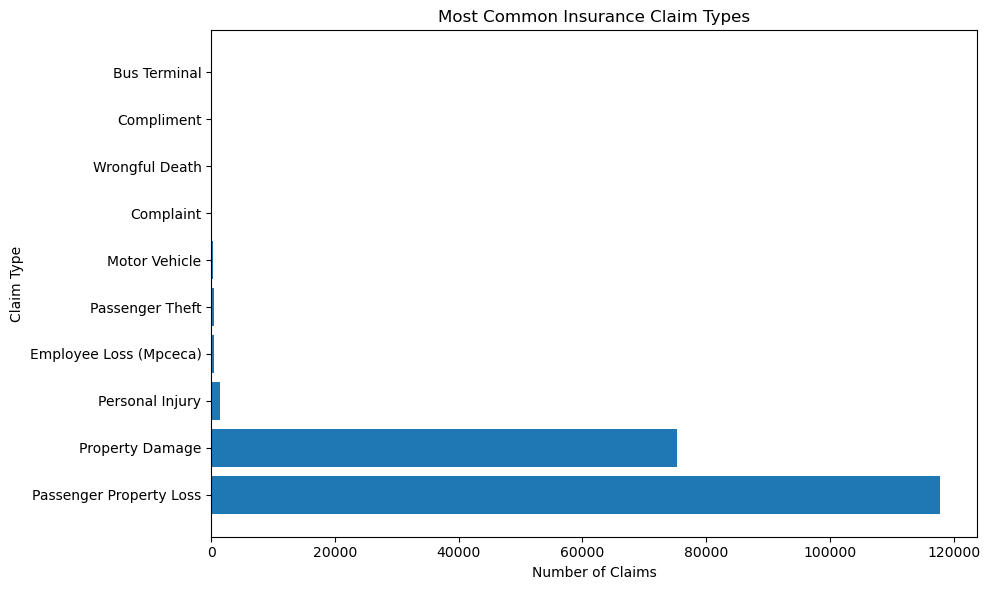

In [ ]:
claim_type_counts = (
    tsa["Claim Type"]
    .dropna()
    .value_counts()
    .reset_index()
)

claim_type_counts.columns = ["Claim Type", "Count"]

print(claim_type_counts)

most_common_claim = claim_type_counts.iloc[0]
print("\nMost common claim type:", most_common_claim["Claim Type"])

plt.figure(figsize=(10,6))
plt.barh(claim_type_counts["Claim Type"], claim_type_counts["Count"])
plt.title("Most Common Insurance Claim Types")
plt.xlabel("Number of Claims")
plt.ylabel("Claim Type")
plt.tight_layout()
plt.show()

# Most Common Type of Insurance Claim

The most common type of insurance claim with TSA, showcase by the bar chart, is passenger property loss.

        Claim Site   Count
0  Checked Baggage  159752
1       Checkpoint   40133
2            Other    2875
3    Motor Vehicle     474
4      Bus Station      16

Claim site with most claims: Checked Baggage


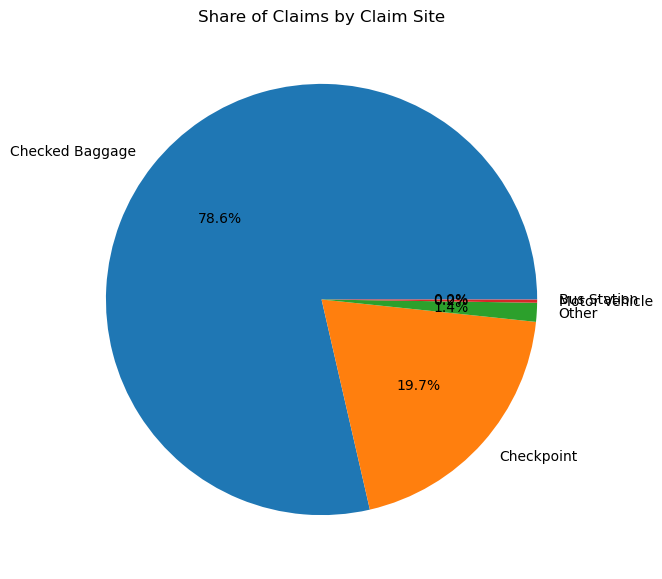

In [ ]:
claim_site_counts = (
    tsa["Claim Site"]
    .dropna()
    .value_counts()
    .reset_index()
)

claim_site_counts.columns = ["Claim Site", "Count"]

print(claim_site_counts)

top_site = claim_site_counts.iloc[0]
print("\nClaim site with most claims:", top_site["Claim Site"])

plt.figure(figsize=(7,7))
plt.pie(
    claim_site_counts["Count"],
    labels=claim_site_counts["Claim Site"],
    autopct="%1.1f%%"
)
plt.title("Share of Claims by Claim Site")
plt.show()

# Claims by Airport Site

The most common claim site within the aiport with the most insurance claims is the checked baggage site, according to the pie chart.

         Claim Site               Claim Type  Count
0       Bus Station  Passenger Property Loss      9
1       Bus Station          Property Damage      7
2   Checked Baggage             Bus Terminal      1
3   Checked Baggage                Complaint     20
4   Checked Baggage               Compliment      1
5   Checked Baggage   Employee Loss (Mpceca)    383
6   Checked Baggage            Motor Vehicle     26
7   Checked Baggage  Passenger Property Loss  99708
8   Checked Baggage          Passenger Theft    396
9   Checked Baggage          Personal Injury    248
10  Checked Baggage          Property Damage  54082
11       Checkpoint                Complaint     21
12       Checkpoint               Compliment      2
13       Checkpoint   Employee Loss (Mpceca)     66
14       Checkpoint            Motor Vehicle      9
15       Checkpoint  Passenger Property Loss  17440
16       Checkpoint          Passenger Theft     66
17       Checkpoint          Personal Injury    974
18       Che

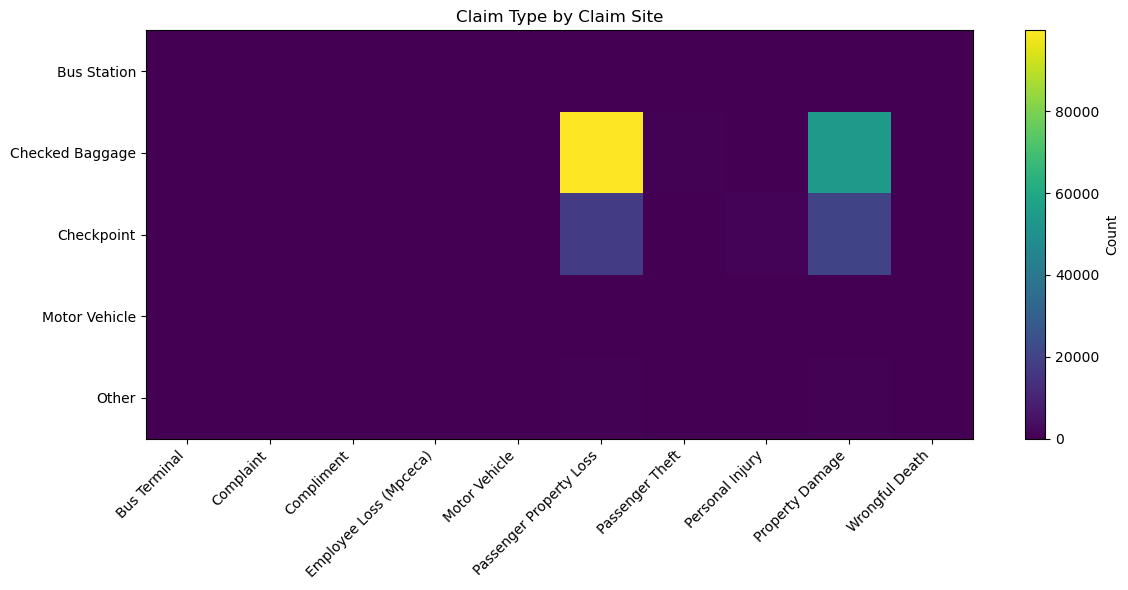

In [ ]:
site_claim_table = (
    tsa.groupby(["Claim Site", "Claim Type"])
    .size()
    .reset_index(name="Count")
)

print(site_claim_table)

most_common_by_site = (
    site_claim_table
    .sort_values(["Claim Site", "Count"], ascending=[True, False])
    .groupby("Claim Site")
    .head(1)
)

print("\nMost common claim type at each site:")
print(most_common_by_site)

pivot_table = site_claim_table.pivot(
    index="Claim Site",
    columns="Claim Type",
    values="Count"
).fillna(0)

plt.figure(figsize=(12,6))
plt.imshow(pivot_table, aspect="auto")
plt.colorbar(label="Count")
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.title("Claim Type by Claim Site")
plt.tight_layout()
plt.show()

# Claim Type by Claim Site

The most popular claim site for passenger property loss was checked baggage, and the most popular claim site for property damage is checked baggage.

count    168587.000000
mean        172.999025
std         208.694719
min           0.000000
25%          20.770000
50%          95.000000
75%         250.000000
max         999.990000
Name: Claim Amount, dtype: float64

Typical claim amount (median): 95.0
Average claim amount (mean): 172.99902507310765


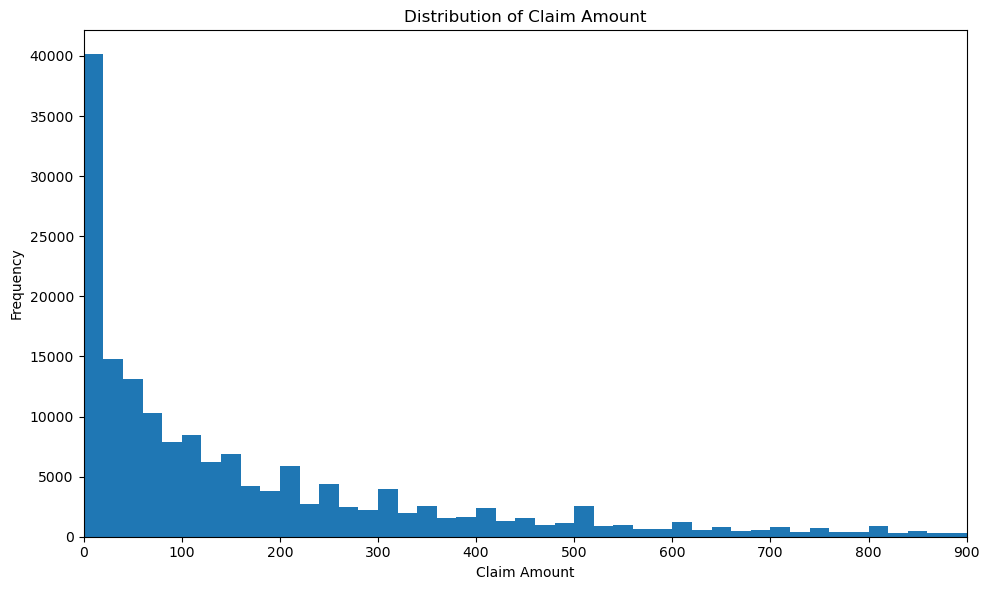

In [ ]:
#summary stats
claim_stats = tsa["Claim Amount"].describe()
print(claim_stats)

median_claim = tsa["Claim Amount"].median()
mean_claim = tsa["Claim Amount"].mean()

print("\nTypical claim amount (median):", median_claim)
print("Average claim amount (mean):", mean_claim)

plt.figure(figsize=(10,6))
plt.hist(tsa["Claim Amount"].dropna(), bins=50)
plt.title("Distribution of Claim Amount")
plt.xlabel("Claim Amount")
plt.ylabel("Frequency")
plt.xlim(0, tsa["Claim Amount"].dropna().quantile(0.99))
plt.tight_layout()
plt.show()

# Typical Claim Amount

The most typical claim amount is 0.

Overall approval rate: 30.83 %

Approval summary:
Approved
False    141289
True      62977
Name: count, dtype: int64


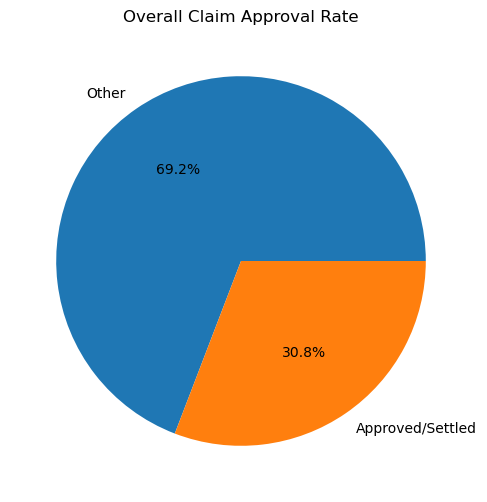

In [ ]:
tsa["Approved"] = tsa["Disposition"].isin(["Approved", "Settled"])

approval_rate = tsa["Approved"].mean() * 100

print("Overall approval rate:", round(approval_rate, 2), "%")

approval_summary = tsa["Approved"].value_counts()
print("\nApproval summary:")
print(approval_summary)

approval_counts = tsa["Approved"].value_counts()

labels = approval_counts.index.map({
    True: "Approved/Settled",
    False: "Other"
})

plt.figure(figsize=(6,6))
plt.pie(
    approval_counts.values,
    labels=labels,
    autopct="%1.1f%%"
)
plt.title("Overall Claim Approval Rate")
plt.show()

# Overall Claim Approval Rate

The overall claim approval rate is 30.83%.

count    58653.000000
mean        79.755543
std         30.210054
min          0.000000
25%         50.000000
50%        100.000000
75%        100.000000
max       3416.333333
Name: Percent Paid, dtype: float64

Overall weighted percent paid: 70.19 %


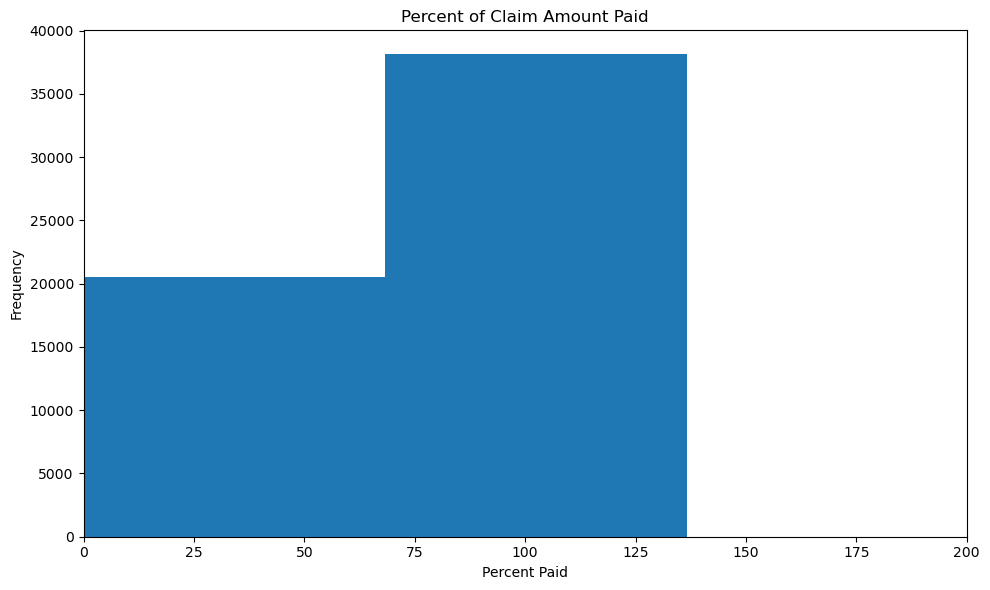

In [ ]:
paid_claims = tsa[
    tsa["Disposition"].isin(["Approved", "Settled"])
].copy()

paid_claims = paid_claims.dropna(subset=["Claim Amount", "Close Amount"])
paid_claims = paid_claims[paid_claims["Claim Amount"] > 0]

paid_claims["Percent Paid"] = (
    paid_claims["Close Amount"] / paid_claims["Claim Amount"]
) * 100

print(paid_claims["Percent Paid"].describe())

overall_percent_paid = (
    paid_claims["Close Amount"].sum() /
    paid_claims["Claim Amount"].sum()
) * 100

print("\nOverall weighted percent paid:", round(overall_percent_paid, 2), "%")

plt.figure(figsize=(10,6))
plt.hist(paid_claims["Percent Paid"], bins=50)
plt.title("Percent of Claim Amount Paid")
plt.xlabel("Percent Paid")
plt.ylabel("Frequency")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# Percent of Claim Amount Paid Amount For

The percent of the claim amount paid for is 70.19%

    Airport Code                          Airport Name  Claims
246          LAX     Los Angeles International Airport    9596
232          JFK         John F. Kennedy International    9232
138          EWR          Newark International Airport    6866
321          ORD  Chicago O'Hare International Airport    6843
288          MIA           Miami International Airport    6432


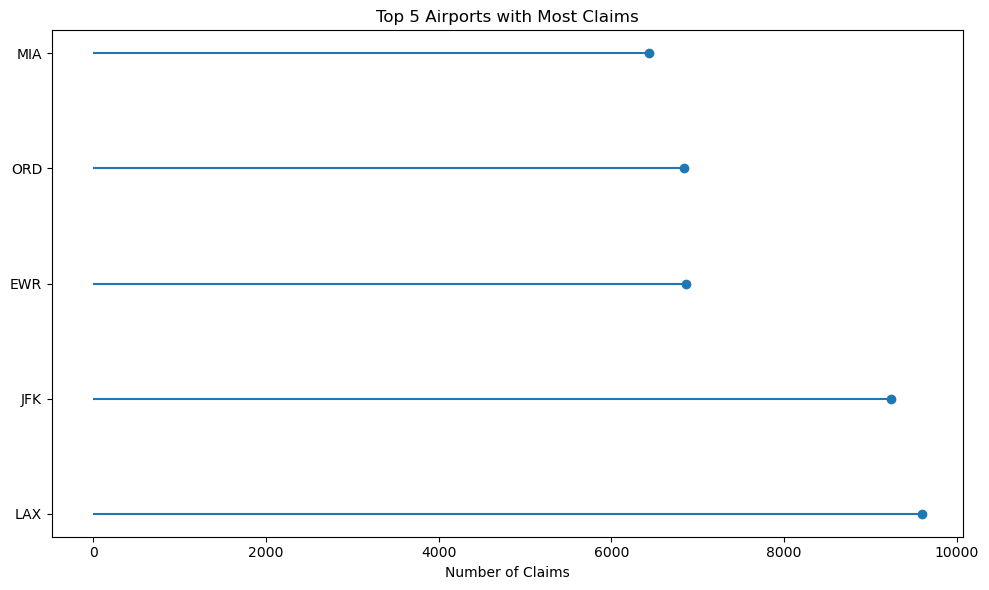

In [ ]:
top_airports = (
    tsa.groupby(["Airport Code", "Airport Name"])
    .size()
    .reset_index(name="Claims")
    .sort_values("Claims", ascending=False)
    .head(5)
)

print(top_airports)
plt.figure(figsize=(10,6))
plt.hlines(
    y=top_airports["Airport Code"],
    xmin=0,
    xmax=top_airports["Claims"]
)
plt.plot(
    top_airports["Claims"],
    top_airports["Airport Code"],
    "o"
)
plt.title("Top 5 Airports with Most Claims")
plt.xlabel("Number of Claims")
plt.tight_layout()
plt.show()

# Top 5 Airports

The top 5 airports with the most claims are pictured, being LAX, JFK, EWR, ORD, and MIA.

    Received Year  Close Amount
0          1940.0          8.48
1          1944.0          0.00
2          1955.0          0.00
3          1994.0         50.00
4          1996.0          0.00
5          2000.0         85.70
6          2002.0     102950.43
7          2003.0    1772028.28
8          2004.0    2401358.94
9          2005.0    1451356.00
10         2006.0    1085467.94
11         2007.0     708277.15
12         2008.0     513127.05
13         2009.0     413987.85
14         2010.0          0.00
15         2011.0          0.00
16         2012.0          0.00
17         2013.0          0.00
18         2014.0          0.00
19         2015.0          0.00
20         2020.0        179.08
21         2025.0        100.00


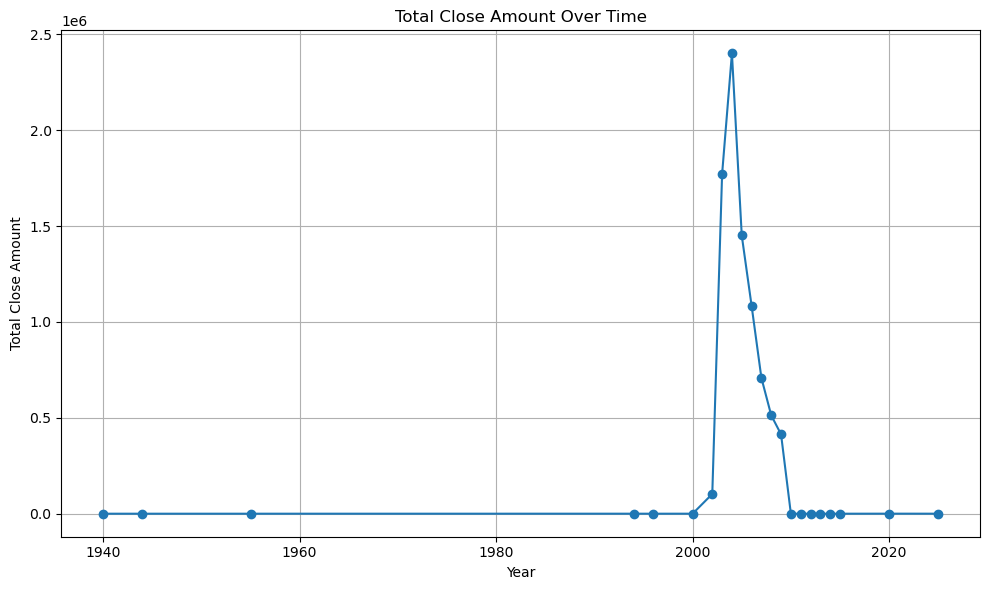


The total close amount has generally increased over time.


In [ ]:
close_trend = (
    tsa.groupby("Received Year")["Close Amount"]
    .sum()
    .reset_index()
    .sort_values("Received Year")
)

print(close_trend)

plt.figure(figsize=(10,6))
plt.plot(close_trend["Received Year"], close_trend["Close Amount"], marker="o")
plt.title("Total Close Amount Over Time")
plt.xlabel("Year")
plt.ylabel("Total Close Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

first_value = close_trend["Close Amount"].iloc[0]
last_value = close_trend["Close Amount"].iloc[-1]

if last_value > first_value:
    print("\nThe total close amount has generally increased over time.")
elif last_value < first_value:
    print("\nThe total close amount has generally decreased over time.")
else:
    print("\nThe total close amount stayed about the same.")

# Total Close Amount

The total close amount has arguably increased over time, but with no real linear relationship.

# Geographic Visualization

In [ ]:
extract_folder = "maps_data"
os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile("maps.zip", "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP extracted successfully")

shp_files = glob.glob("maps_data/**/*.shp", recursive=True)

print("Shapefile found:")
print(shp_files)

ZIP extracted successfully
Shapefile found:
['maps_data/maps/states.shp']


In [ ]:
states = gpd.read_file(shp_files[0])

print(states.head())

     STATE_NAME  DRAWSEQ STATE_FIPS          SUB_REGION STATE_ABBR  \
0        Hawaii        1         15             Pacific         HI   
1    Washington        2         53             Pacific         WA   
2       Montana        3         30            Mountain         MT   
3         Maine        4         23         New England         ME   
4  North Dakota        5         38  West North Central         ND   

                                            geometry  
0  MULTIPOLYGON (((-160.0738 22.00418, -160.04971...  
1  MULTIPOLYGON (((-122.40202 48.22522, -122.4628...  
2  POLYGON ((-111.47543 44.70216, -111.4808 44.69...  
3  MULTIPOLYGON (((-69.77728 44.07415, -69.85993 ...  
4  POLYGON ((-98.73044 45.93827, -99.00683 45.939...  


In [ ]:
#build the airport claim counts

airport_claims = (
    tsa.groupby("Airport Code")
    .size()
    .reset_index(name="Claims")
)

print(airport_claims.head())

  Airport Code  Claims
0          ABE     129
1          ABI      46
2          ABQ     936
3          ABR      31
4          ABY      37


In [ ]:
#merge with the airport coordinates

airport_map = airport_claims.merge(
    airports_us,
    left_on="Airport Code",
    right_on="IATACode",
    how="left"
)

airport_map = airport_map.dropna(
    subset=["LatitudeDecimalDegrees", "LongitudeDecimalDegrees"]
)

In [ ]:
#convert to a geodataframe
airport_gdf = gpd.GeoDataFrame(
    airport_map,
    geometry=gpd.points_from_xy(
        airport_map["LongitudeDecimalDegrees"],
        airport_map["LatitudeDecimalDegrees"]
    ),
    crs="EPSG:4326"
)

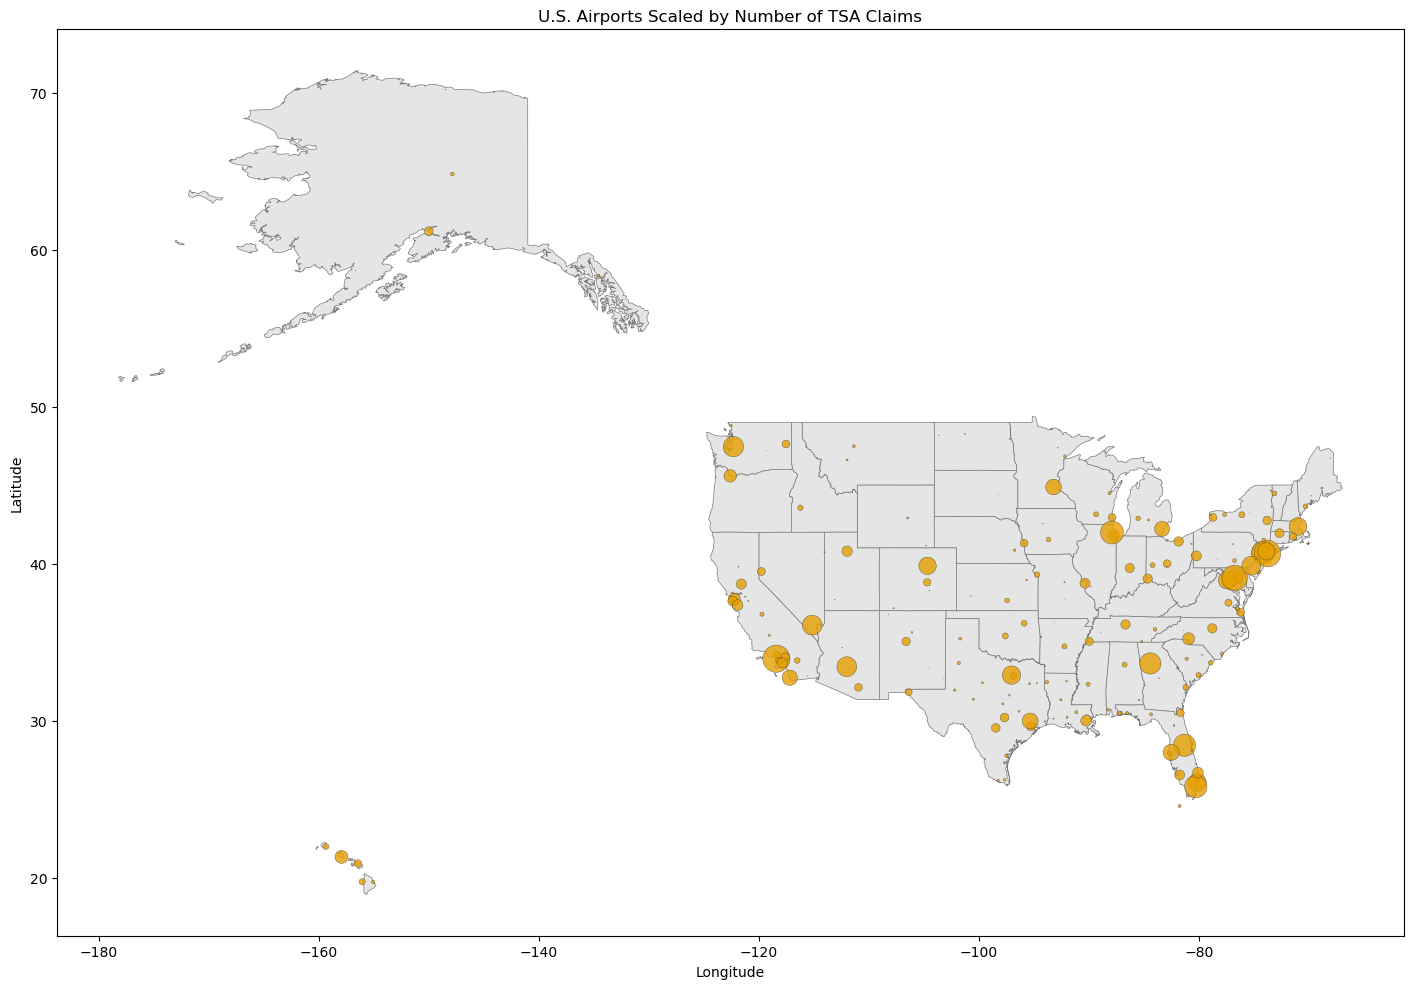

In [ ]:
fig, ax = plt.subplots(figsize=(16,10))

# plot the U.S. map
states.plot(
    ax=ax,
    color="#E5E5E5",      # light gray map
    edgecolor="#7A7A7A",
    linewidth=0.5
)

# plot the airport bubbles scaled by claims
airport_gdf.plot(
    ax=ax,
    markersize=airport_gdf["Claims"] / 25,
    color="#E69F00",      # colorblind-friendly orange
    edgecolor="#333333",
    linewidth=0.3,
    alpha=0.8
)

plt.title("U.S. Airports Scaled by Number of TSA Claims")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()